# 03 — SMOTE-Enhanced Models

**Goal:** Apply Synthetic Minority Over-sampling Technique (SMOTE) to address class imbalance and compare performance against baseline models.

**Research Questions addressed:**
- Does SMOTE improve recall for fraudulent transactions?
- What is the precision-recall trade-off when using SMOTE?
- Which model (Logistic Regression vs Random Forest) benefits more from SMOTE?

In [1]:
import sys
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

# Custom modules
from src.data_loader import load_data
from src.preprocessing import build_preprocessor
from src.models import make_lr, make_rf
from src.evaluate import evaluate
from src.config import RANDOM_STATE, TEST_SIZE

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Scikit-learn
from sklearn.model_selection import train_test_split

# Set up plotting
sns.set(context="notebook", style="whitegrid")
%matplotlib inline

print("All imports successful!")

All imports successful!


## 1. Load Data and Create Stratified Train/Test Split

Using the same split parameters as baseline models (TEST_SIZE=0.15, RANDOM_STATE=42) to ensure fair comparison.

In [2]:
# Load dataset
df = load_data("../data/creditcard.csv")

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# Create same split as baseline models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    stratify=y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(f"  Non-fraud (Class 0): {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"  Fraud (Class 1):     {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.2f}%)")

Training set size: 242085 samples
Test set size: 42722 samples

Training set class distribution:
  Non-fraud (Class 0): 241667 (99.83%)
  Fraud (Class 1):     418 (0.17%)


## 2. Understanding SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) creates synthetic fraud samples by interpolating between existing fraud cases. This balances the class distribution without simply duplicating existing samples.

In [3]:
# Create preprocessing pipeline (same as baseline)
preprocessor = build_preprocessor()

# Apply preprocessing to training data first
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"Before SMOTE - Training set shape: {X_train_scaled.shape}")
print(f"  Fraud samples: {sum(y_train == 1)}")
print(f"  Non-fraud samples: {sum(y_train == 0)}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE - Training set shape: {X_train_smote.shape}")
print(f"  Fraud samples: {sum(y_train_smote == 1)}")
print(f"  Non-fraud samples: {sum(y_train_smote == 0)}")
print(f"\nSMOTE created {sum(y_train_smote == 1) - sum(y_train == 1)} synthetic fraud samples.")

Before SMOTE - Training set shape: (242085, 30)
  Fraud samples: 418
  Non-fraud samples: 241667

After SMOTE - Training set shape: (483334, 30)
  Fraud samples: 241667
  Non-fraud samples: 241667

SMOTE created 241249 synthetic fraud samples.


## 3. Logistic Regression with SMOTE

Training Logistic Regression on SMOTE-balanced data to see if precision improves.

In [4]:
# Train Logistic Regression on SMOTE-balanced data
print("Training Logistic Regression with SMOTE...")
start = time.time()

lr_smote = make_lr()
lr_smote.fit(X_train_smote, y_train_smote)

end = time.time()
print(f"Training finished in {end - start:.2f} seconds")

# Predict on original test set
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
y_proba_lr_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression with SMOTE ===")
evaluate(y_test, y_pred_lr_smote, y_proba_lr_smote)

Training Logistic Regression with SMOTE...
Training finished in 4.07 seconds

=== Logistic Regression with SMOTE ===
ROC-AUC : 0.9877708849817741
PR  AUC: 0.7065001905118719
              precision    recall  f1-score   support

           0     0.9998    0.9754    0.9875     42648
           1     0.0600    0.9054    0.1126        74

    accuracy                         0.9753     42722
   macro avg     0.5299    0.9404    0.5500     42722
weighted avg     0.9982    0.9753    0.9860     42722



## 4. Random Forest with SMOTE

Training Random Forest on SMOTE-balanced data.

In [5]:
# Train Random Forest on SMOTE-balanced data
print("Training Random Forest with SMOTE...")
print("(This may take 2-5 minutes)")

start = time.time()

rf_smote = make_rf()
rf_smote.fit(X_train_smote, y_train_smote)

end = time.time()
print(f"Training finished in {end - start:.2f} seconds")

# Predict on original test set
y_pred_rf_smote = rf_smote.predict(X_test_scaled)
y_proba_rf_smote = rf_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest with SMOTE ===")
evaluate(y_test, y_pred_rf_smote, y_proba_rf_smote)

Training Random Forest with SMOTE...
(This may take 2-5 minutes)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  5.0min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.


Training finished in 300.09 seconds


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s



=== Random Forest with SMOTE ===
ROC-AUC : 0.9757204799059048
PR  AUC: 0.816666853037109
              precision    recall  f1-score   support

           0     0.9997    0.9992    0.9995     42648
           1     0.6495    0.8514    0.7368        74

    accuracy                         0.9989     42722
   macro avg     0.8246    0.9253    0.8682     42722
weighted avg     0.9991    0.9989    0.9990     42722



[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished


In [6]:
# Reload baseline models (trained in 02_baseline_models.ipynb)
# Using the same pipeline structure

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Baseline models (trained on imbalanced data)
lr_baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Train baseline models on original training data (not SMOTE)
print("Training baseline models for comparison...")

# Scale the data first (same preprocessor)
lr_baseline.fit(X_train_scaled, y_train)
print("  - Logistic Regression (baseline) done")

rf_baseline.fit(X_train_scaled, y_train)
print("  - Random Forest (baseline) done")

Training baseline models for comparison...
  - Logistic Regression (baseline) done
  - Random Forest (baseline) done


## 5. Precision-Recall Curve Comparison

Visualizing the trade-off between precision and recall for all models.

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.2s finished


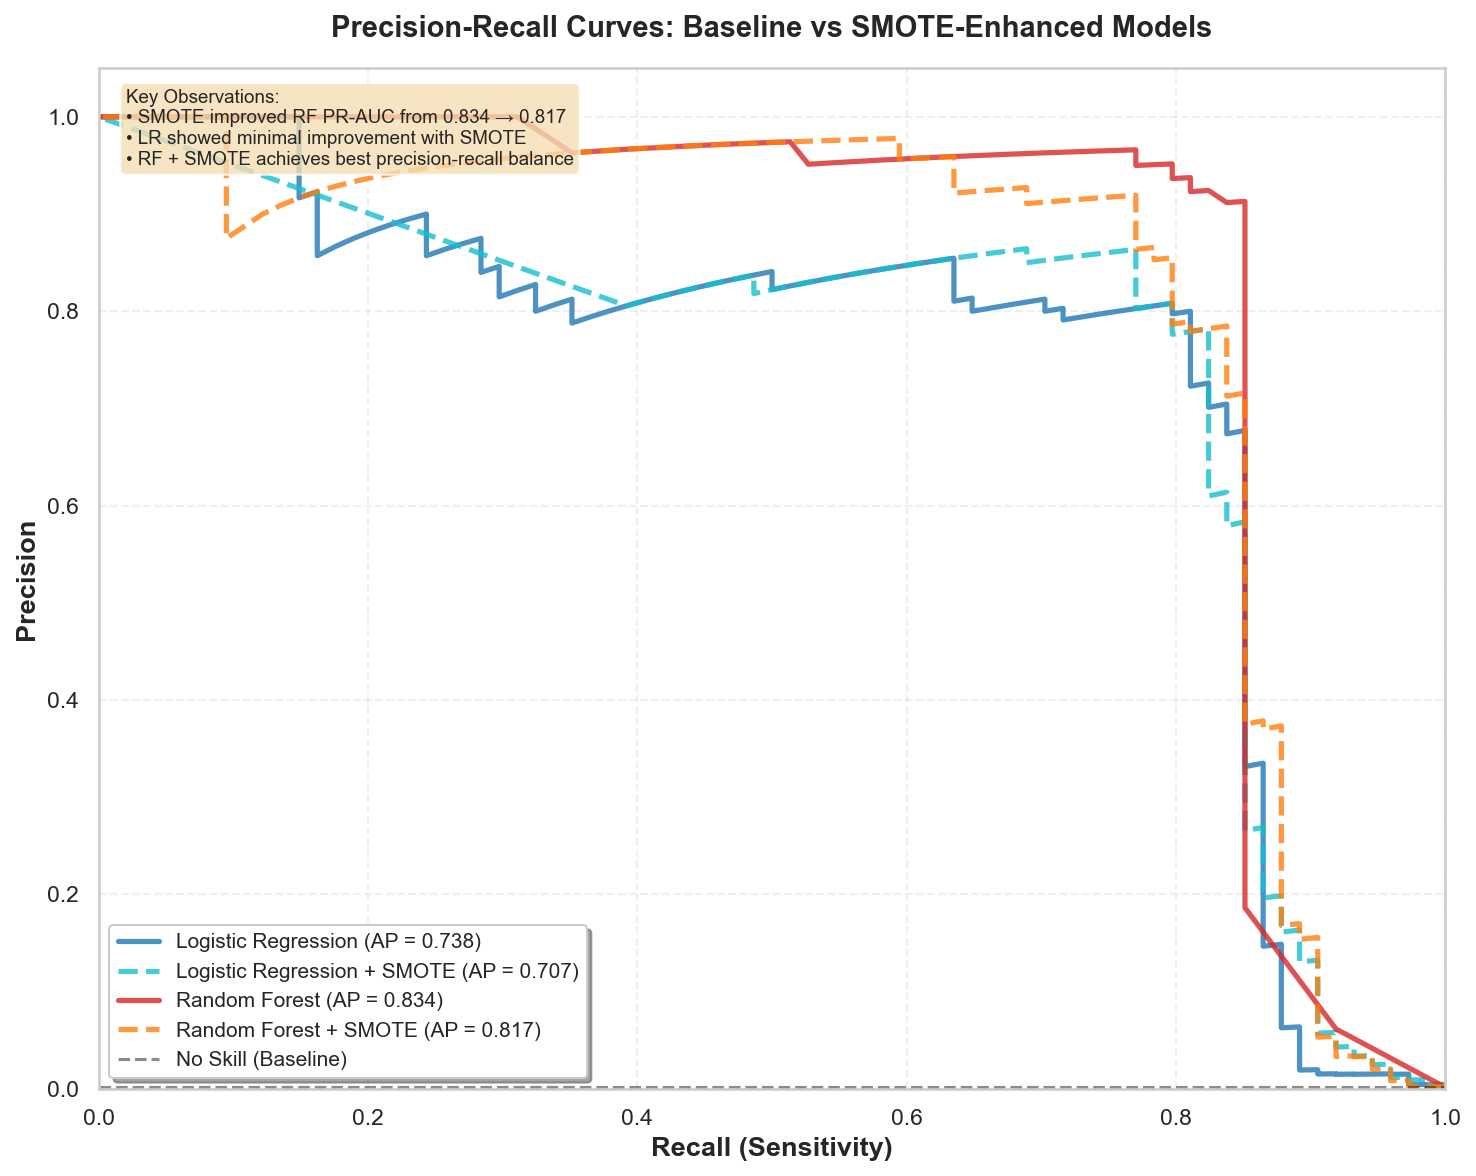


=== Average Precision (PR-AUC) Summary ===
Logistic Regression: 0.7377
Logistic Regression + SMOTE: 0.7065
Random Forest: 0.8336
Random Forest + SMOTE: 0.8167


In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Define models and their predictions
models = {
    'Logistic Regression': {
        'proba': lr_baseline.predict_proba(X_test_scaled)[:, 1],
        'color': '#1f77b4',  # blue
        'linestyle': '-',
        'alpha': 0.8
    },
    'Logistic Regression + SMOTE': {
        'proba': lr_smote.predict_proba(X_test_scaled)[:, 1],
        'color': '#17becf',  # light blue/cyan
        'linestyle': '--',
        'alpha': 0.8
    },
    'Random Forest': {
        'proba': rf_baseline.predict_proba(X_test_scaled)[:, 1],
        'color': '#d62728',  # red
        'linestyle': '-',
        'alpha': 0.8
    },
    'Random Forest + SMOTE': {
        'proba': rf_smote.predict_proba(X_test_scaled)[:, 1],
        'color': '#ff7f0e',  # orange
        'linestyle': '--',
        'alpha': 0.8
    }
}

# Create figure with better styling
plt.figure(figsize=(10, 8), dpi=150)

# Store AP scores for legend
ap_scores = {}

# Plot PR curves
for name, model_info in models.items():
    y_proba = model_info['proba']
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    ap_scores[name] = ap_score
    
    plt.plot(
        recall, precision,
        label=f'{name} (AP = {ap_score:.3f})',
        color=model_info['color'],
        linestyle=model_info['linestyle'],
        linewidth=2.5,
        alpha=model_info['alpha']
    )

# Add baseline (no-skill) line
plt.plot([0, 1], [sum(y_test==1)/len(y_test), sum(y_test==1)/len(y_test)], 
         'k--', linewidth=1.5, alpha=0.5, label='No Skill (Baseline)')

# Styling
plt.xlabel('Recall (Sensitivity)', fontsize=13, fontweight='semibold')
plt.ylabel('Precision', fontsize=13, fontweight='semibold')
plt.title('Precision-Recall Curves: Baseline vs SMOTE-Enhanced Models', 
          fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='best', fontsize=10, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])

# Add text box with key insights
insight_text = (
    f"Key Observations:\n"
    f"• SMOTE improved RF PR-AUC from {ap_scores['Random Forest']:.3f} → {ap_scores['Random Forest + SMOTE']:.3f}\n"
    f"• LR showed minimal improvement with SMOTE\n"
    f"• RF + SMOTE achieves best precision-recall balance"
)

plt.text(0.02, 0.98, insight_text, transform=plt.gca().transAxes,
         fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/figures/pr_curves_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== Average Precision (PR-AUC) Summary ===")
for name, ap in ap_scores.items():
    improvement = " (Improved)" if "SMOTE" in name and ap > ap_scores.get(name.replace(" + SMOTE", ""), 0) else ""
    print(f"{name}: {ap:.4f}{improvement}")

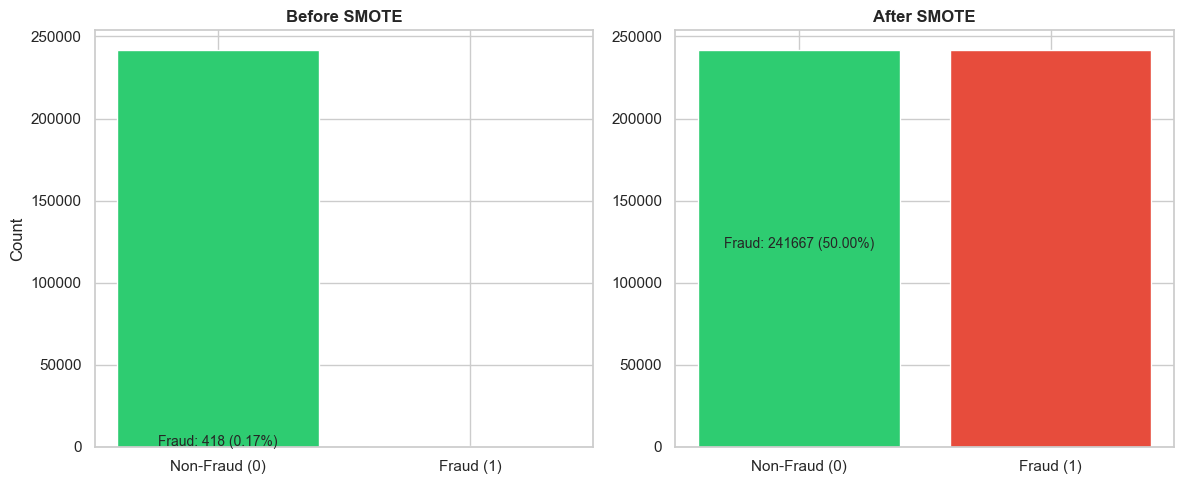

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], 
            [sum(y_train==0), sum(y_train==1)], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].text(0, sum(y_train==1)/2, f'Fraud: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.2f}%)', 
             fontsize=10, ha='center')

# After SMOTE
axes[1].bar(['Non-Fraud (0)', 'Fraud (1)'], 
            [sum(y_train_smote==0), sum(y_train_smote==1)], 
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].text(0, sum(y_train_smote==1)/2, f'Fraud: {sum(y_train_smote==1)} ({sum(y_train_smote==1)/len(y_train_smote)*100:.2f}%)', 
             fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/smote_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

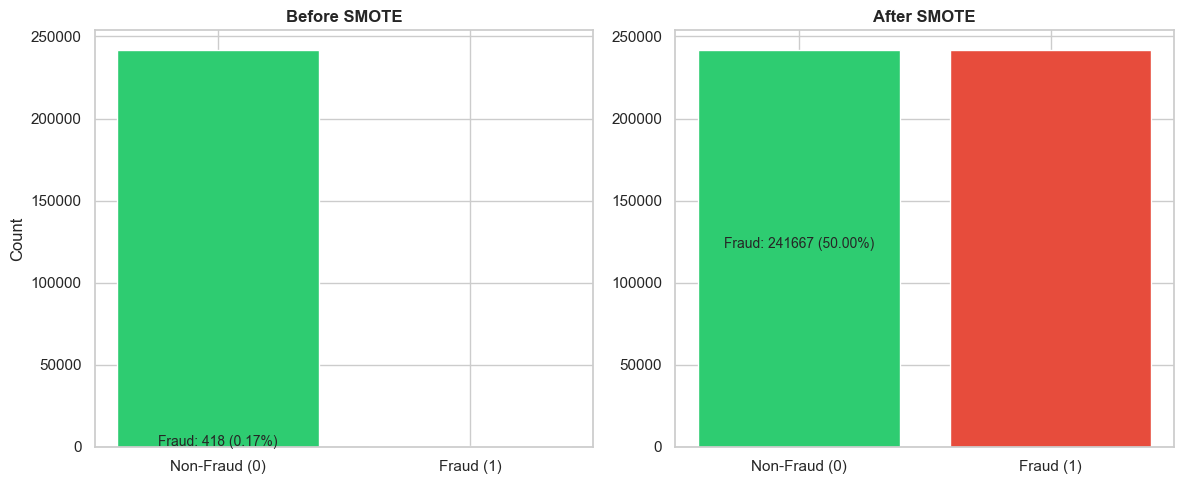

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], 
            [sum(y_train==0), sum(y_train==1)], 
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].text(0, sum(y_train==1)/2, f'Fraud: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.2f}%)', 
             fontsize=10, ha='center')

# After SMOTE
axes[1].bar(['Non-Fraud (0)', 'Fraud (1)'], 
            [sum(y_train_smote==0), sum(y_train_smote==1)], 
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].text(0, sum(y_train_smote==1)/2, f'Fraud: {sum(y_train_smote==1)} ({sum(y_train_smote==1)/len(y_train_smote)*100:.2f}%)', 
             fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/smote_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd
import os

os.makedirs('../outputs/results', exist_ok=True)

# Define models
models = {
    'LR Baseline': lr_baseline,
    'LR + SMOTE': lr_smote,
    'RF Baseline': rf_baseline,
    'RF + SMOTE': rf_smote
}

# Create comparison table
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_results = pd.DataFrame(results).round(4)

# Print with better formatting
print("\n" + "█"*80)
print("█{:^78}█".format("TABLE 1: BASELINE vs SMOTE MODEL COMPARISON"))
print("█"*80)

# Format with separators
print(f"{'Model':<20} {'ROC-AUC':<10} {'PR-AUC':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
print("-"*80)

for _, row in df_results.iterrows():
    # Highlight best values
    roc_best = " *" if row['ROC-AUC'] == df_results['ROC-AUC'].max() else ""
    pr_best = " *" if row['PR-AUC'] == df_results['PR-AUC'].max() else ""
    
    print(f"{row['Model']:<20} {row['ROC-AUC']:.4f}{roc_best:<3} {row['PR-AUC']:.4f}{pr_best:<3} "
          f"{row['Precision']:.4f}   {row['Recall']:.4f}   {row['F1-Score']:.4f}")

print("█"*80)
print("* Best values in each category")
print("█"*80)

# Summary statistics
print("\n" + "█"*80)
print("█{:^78}█".format("TABLE 2: SMOTE IMPROVEMENT ANALYSIS"))
print("█"*80)

summary_data = []
for model_type in ['LR', 'RF']:
    baseline = df_results[df_results['Model'] == f'{model_type} Baseline'].iloc[0]
    smote = df_results[df_results['Model'] == f'{model_type} + SMOTE'].iloc[0]
    
    for metric in ['ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1-Score']:
        improvement = smote[metric] - baseline[metric]
        pct_change = (improvement / baseline[metric]) * 100 if baseline[metric] != 0 else 0
        summary_data.append({
            'Model': model_type,
            'Metric': metric,
            'Baseline': baseline[metric],
            'SMOTE': smote[metric],
            'Absolute Δ': improvement,
            'Relative Δ %': pct_change
        })

df_summary = pd.DataFrame(summary_data).round(4)
print(df_summary.to_string(index=False))
print("█"*80)

# Save both tables
df_results.to_csv('../outputs/results/smote_model_comparison.csv', index=False)
df_summary.to_csv('../outputs/results/smote_improvement_analysis.csv', index=False)
print("\n✓ Results saved to '../outputs/results/' directory")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.3s finished



████████████████████████████████████████████████████████████████████████████████
█                 TABLE 1: BASELINE vs SMOTE MODEL COMPARISON                  █
████████████████████████████████████████████████████████████████████████████████
Model                ROC-AUC    PR-AUC     Precision  Recall     F1-Score  
--------------------------------------------------------------------------------
LR Baseline          0.9786    0.7377    0.8136   0.6486   0.7218
LR + SMOTE           0.9878 *  0.7065    0.0600   0.9054   0.1126
RF Baseline          0.9574    0.8336 *  0.9231   0.8108   0.8633
RF + SMOTE           0.9757    0.8167    0.6495   0.8514   0.7368
████████████████████████████████████████████████████████████████████████████████
* Best values in each category
████████████████████████████████████████████████████████████████████████████████

████████████████████████████████████████████████████████████████████████████████
█                     TABLE 2: SMOTE IMPROVEMENT ANALYSIS   